## First Mission

Growth Audit: Marketing claims our App Conversion Rate is ~78%. 

Task: Recalculate the conversion rate based on a stricter definition that aligns with sustainable economic behavior for the bank. Explain the discrepancy between your number and Marketing's.

Execution Breakdown:
- Reverse-engineer Marketing`s 78% and document premisses used
- Recreate a more accurate way of evaluate this metric
- Compare both premisses and describe why is important to use the second method instead of the Marketing method 

##### Imports

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("fraud_prevention_data.csv")
df.head()

,USER_ID,TYPE,AMOUNT,CURRENCY,MERCHANT_COUNTRY,KYC,BIRTH_YEAR,COUNTRY,IS_FRAUD
0,7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,AUS,PASSED,1963,GB,False
1,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,CA,PASSED,1988,GB,False
2,0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,UKR,PASSED,1977,GB,False
3,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,CA,PASSED,1988,GB,False
4,821014c5-af06-40ff-91f4-77fe7667809f,CARD_PAYMENT,968,GBP,NZL,FAILED,1992,GB,False


##### Treat Country Columns

In [2]:
# Import ISO country code table

country_codes = pd.read_excel("CountryCodesTable_ISO3166.xlsx")
country_codes["Numeric_3"] = (
    country_codes["Numeric"]
    .astype(str)
    .str.strip()
    .str.zfill(3)
)

country_codes.head()

,Country,Alpha-2-code,Alpha-3-code,Numeric,Numeric_3
0,Afghanistan,AF,AFG,4,004
1,Albania,AL,ALB,8,008
2,Algeria,DZ,DZA,12,012
3,American Samoa,AS,ASM,16,016
4,Andorra,AD,AND,20,020


In [4]:
## Creating From/To Dictionary

iso2_to_country_name = dict(
    zip(country_codes["Alpha-2-code"], country_codes["Country"])
)

iso3_to_country_name = dict(
    zip(country_codes["Alpha-3-code"], country_codes["Country"])
)

numeric_to_country_name = dict(
    zip(country_codes["Numeric_3"], country_codes["Country"])
)

manual_country_mapping = {
    "ROM": "Romania",
    "BP0": "Hungary",
    "BP1": "Hungary",
    "BP2": "Hungary",
    "NSW": "New South Wales",
    "FL" : "Liechtenstein"
}

country_depara = {}
country_depara.update(iso2_to_country_name)
country_depara.update(iso3_to_country_name)
country_depara.update(numeric_to_country_name)
country_depara.update(manual_country_mapping)

country_depara

{'AF': 'Afghanistan',
 'AL': 'Albania',
 'DZ': 'Algeria',
 'AS': 'American Samoa',
 'AD': 'Andorra',
 'AO': 'Angola',
 'AI': 'Anguilla',
 'AQ': 'Antarctica',
 'AG': 'Antigua and Barbuda',
 'AR': 'Argentina',
 'AM': 'Armenia',
 'AW': 'Aruba',
 'AU': 'Australia',
 'AT': 'Austria',
 'AZ': 'Azerbaijan',
 'BS': 'Bahamas (the)',
 'BH': 'Bahrain',
 'BD': 'Bangladesh',
 'BB': 'Barbados',
 'BY': 'Belarus',
 'BE': 'Belgium',
 'BZ': 'Belize',
 'BJ': 'Benin',
 'BM': 'Bermuda',
 'BT': 'Bhutan',
 'BO': 'Bolivia (Plurinational State of)',
 'BQ': 'Bonaire, Sint Eustatius and Saba',
 'BA': 'Bosnia and Herzegovina',
 'BW': 'Botswana',
 'BV': 'Bouvet Island',
 'BR': 'Brazil',
 'IO': 'British Indian Ocean Territory (the)',
 'BN': 'Brunei Darussalam',
 'BG': 'Bulgaria',
 'BF': 'Burkina Faso',
 'BI': 'Burundi',
 'CV': 'Cabo Verde',
 'KH': 'Cambodia',
 'CM': 'Cameroon',
 'CA': 'Canada',
 'KY': 'Cayman Islands (the)',
 'CF': 'Central African Republic (the)',
 'TD': 'Chad',
 'CL': 'Chile',
 'CN': 'China',
 'CX

In [9]:
# Clean COUNTRY
df["COUNTRY_CLEAN"] = (
    df["COUNTRY"]
    .astype(str)
    .str.strip()
    .str.upper()
)

# Apply De/Para to COUNTRY
df["COUNTRY_NAME"] = df["COUNTRY_CLEAN"].map(country_depara)

In [10]:
## COUNTRY Mapping check

total_rows = len(df)

mapped_rows = df["COUNTRY_NAME"].notna().sum()
unmapped_rows = df["COUNTRY_NAME"].isna().sum()

print(f"Total rows: {total_rows}")
print(f"Mapped rows: {mapped_rows}")
print(f"Unmapped rows: {unmapped_rows}")
print(f"Mapped %: {mapped_rows / total_rows * 100:.2f}%")
print(f"Unmapped %: {unmapped_rows / total_rows * 100:.2f}%")

Total rows: 688651
Mapped rows: 688651
Unmapped rows: 0
Mapped %: 100.00%
Unmapped %: 0.00%


In [11]:
# Clean MERCHANT_COUNTRY

df["MERCHANT_COUNTRY_CLEAN"] = (
    df["MERCHANT_COUNTRY"]
    .astype(str)
    .str.replace("%20", " ", regex=False)
    .str.strip()
    .str.upper()
)

# Extract country/location code
df["MERCHANT_COUNTRY_EXTRACTED"] = np.select(
    [
        df["MERCHANT_COUNTRY_CLEAN"].str.fullmatch(r"BP\d+"),
        df["MERCHANT_COUNTRY_CLEAN"].str.fullmatch(r"\d{1,3}"),
    ],
    [
        df["MERCHANT_COUNTRY_CLEAN"],
        df["MERCHANT_COUNTRY_CLEAN"].str.zfill(3),
    ],
    default=df["MERCHANT_COUNTRY_CLEAN"].str.extract(r"([A-Z]{2,3})$")[0]
)

# Apply De/Para
df["MERCHANT_COUNTRY_NAME"] = df["MERCHANT_COUNTRY_EXTRACTED"].map(country_depara)

# Keep original nulls as null
original_null = df["MERCHANT_COUNTRY"].isna()

# If not null and mapping failed, classify as "Other"
df["MERCHANT_COUNTRY_NAME"] = df["MERCHANT_COUNTRY_NAME"].where(
    df["MERCHANT_COUNTRY_NAME"].notna() | original_null,
    "Other"
)

In [12]:
## MERCHANT_COUNTRY Mapping check

total_rows = len(df)

mapped_rows = df["MERCHANT_COUNTRY_NAME"].notna().sum()
unmapped_rows = df["MERCHANT_COUNTRY_NAME"].isna().sum()

print(f"Total rows: {total_rows}")
print(f"Mapped rows: {mapped_rows}")
print(f"Unmapped rows: {unmapped_rows}")
print(f"Mapped %: {mapped_rows / total_rows * 100:.2f}%")
print(f"Unmapped %: {unmapped_rows / total_rows * 100:.2f}%")

Total rows: 688651
Mapped rows: 483073
Unmapped rows: 205578
Mapped %: 70.15%
Unmapped %: 29.85%


In [13]:
## NaN rows

unmapped_merchant_country_counts = (
    df[df["MERCHANT_COUNTRY_NAME"].isna()]
    .groupby(
        [
            "MERCHANT_COUNTRY",
            "MERCHANT_COUNTRY_CLEAN",
            "MERCHANT_COUNTRY_EXTRACTED"
        ],
        dropna=False
    )
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)

unmapped_merchant_country_counts["pct_total_rows"] = (
    unmapped_merchant_country_counts["rows"] / len(df) * 100
).round(2)

unmapped_merchant_country_counts.head(50)

,MERCHANT_COUNTRY,MERCHANT_COUNTRY_CLEAN,MERCHANT_COUNTRY_EXTRACTED,rows,pct_total_rows
0,NaN,NAN,NAN,205578,29.85


In [14]:
columns_to_drop = [
    "COUNTRY",
    "COUNTRY_CLEAN",
    "MERCHANT_COUNTRY",
    "MERCHANT_COUNTRY_CLEAN",
    "MERCHANT_COUNTRY_EXTRACTED"
]

df_final = df.drop(columns=columns_to_drop, errors="ignore")

df_final.head()

,USER_ID,TYPE,AMOUNT,CURRENCY,KYC,BIRTH_YEAR,IS_FRAUD,COUNTRY_NAME,MERCHANT_COUNTRY_NAME
0,7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,PASSED,1963,False,United Kingdom of Great Britain and Northern I...,Australia
1,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern I...,Canada
2,0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,PASSED,1977,False,United Kingdom of Great Britain and Northern I...,Ukraine
3,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern I...,Canada
4,821014c5-af06-40ff-91f4-77fe7667809f,CARD_PAYMENT,968,GBP,FAILED,1992,False,United Kingdom of Great Britain and Northern I...,New Zealand


##### Raw Data Exploring

In [ ]:
## Database Structure

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 688651
Columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688651 entries, 0 to 688650
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   USER_ID           688651 non-null  object
 1   TYPE              688651 non-null  object
 2   AMOUNT            688651 non-null  int64 
 3   CURRENCY          688651 non-null  object
 4   MERCHANT_COUNTRY  483073 non-null  object
 5   KYC               688651 non-null  object
 6   BIRTH_YEAR        688651 non-null  int64 
 7   COUNTRY           688651 non-null  object
 8   IS_FRAUD          688651 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 42.7+ MB


In [ ]:
## Describing

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
USER_ID,688651,8021,84e22e7f-f2ab-413c-969a-667c78d8885c,2725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPE,688651,5,CARD_PAYMENT,436570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AMOUNT,688651.0,NaN,NaN,NaN,31725.748835,2304380.77459,0.0,480.0,1420.0,5000.0,900000000.0
CURRENCY,688651,29,GBP,339091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MERCHANT_COUNTRY,483073,362,GBR,146200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
KYC,688651,4,PASSED,677781,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BIRTH_YEAR,688651.0,NaN,NaN,NaN,1984.753271,9.906563,1927.0,1980.0,1987.0,1992.0,2000.0
COUNTRY,688651,56,GB,385343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IS_FRAUD,688651,2,False,674108,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
## Null

null_summary = pd.DataFrame({
    "null_count": df.isna().sum(),
    "null_pct": df.isna().mean() * 100,
})

null_summary

,null_count,null_pct
USER_ID,0,0.000000
TYPE,0,0.000000
AMOUNT,0,0.000000
CURRENCY,0,0.000000
MERCHANT_COUNTRY,205578,29.852276
KYC,0,0.000000
BIRTH_YEAR,0,0.000000
COUNTRY,0,0.000000
IS_FRAUD,0,0.000000


In [11]:
## Different values

unique_summary = pd.DataFrame({
    "unique_values": df.nunique(dropna=False),
})

unique_summary

,unique_values
USER_ID,8021
TYPE,5
AMOUNT,32257
CURRENCY,29
MERCHANT_COUNTRY,363
KYC,4
BIRTH_YEAR,68
COUNTRY,56
IS_FRAUD,2


In [ ]:
## Understanding categorical columns

categorical_cols = ["TYPE", "CURRENCY", "MERCHANT_COUNTRY", "KYC", "COUNTRY", "IS_FRAUD"]

for col in categorical_cols:
    print(f"\n--- {col.upper()} ---")
    display(df[col].value_counts(dropna=False).head(20))


--- TYPE ---


TYPE
CARD_PAYMENT     436570
TOPUP            132561
P2P               56338
ATM               47324
BANK_TRANSFER     15858
Name: count, dtype: int64


--- CURRENCY ---


CURRENCY
GBP    339091
EUR    264695
USD     31542
PLN     22362
RON      5837
CHF      5761
NOK      2602
AUD      2110
DKK      1711
SEK      1579
CZK      1507
CAD      1463
HUF      1446
ZAR      1126
AED       847
JPY       733
NZD       717
THB       690
ILS       522
SGD       487
Name: count, dtype: int64


--- MERCHANT_COUNTRY ---


MERCHANT_COUNTRY
NaN    205578
GBR    146200
USA     46050
FRA     28980
IRL     26196
LTU     25597
ESP     23329
NLD     18532
AUS     10088
POL     10028
ITA      9704
DEU      8522
LUX      8023
CAN      5730
NZL      5254
PRT      5002
CHE      4642
GRC      4536
HUN      4210
SWE      3959
Name: count, dtype: int64


--- KYC ---


KYC
PASSED     677781
NONE         5607
PENDING      2909
FAILED       2354
Name: count, dtype: int64


--- COUNTRY ---


COUNTRY
GB    385343
FR     60184
LT     50725
IE     44731
PL     25725
ES     19510
DE      9012
LV      8526
GR      8458
PT      8402
RO      6903
CH      6485
NL      6102
IT      4973
GI      4473
CY      4278
EE      3830
MT      3632
HU      3286
SK      3280
Name: count, dtype: int64


--- IS_FRAUD ---


IS_FRAUD
False    674108
True      14543
Name: count, dtype: int64

In [ ]:
## Rare values

for col in categorical_cols:
    print(f"\n--- Rare values in {col.upper()} ---")
    counts = df[col].value_counts(dropna=False)
    display(counts[counts <= 2])


--- Rare values in TYPE ---


Series([], Name: count, dtype: int64)


--- Rare values in CURRENCY ---


Series([], Name: count, dtype: int64)


--- Rare values in MERCHANT_COUNTRY ---


MERCHANT_COUNTRY
ACT    2
356    2
455    2
QUI    2
105    2
      ..
VGB    1
AIA    1
GRL    1
DZA    1
OWN    1
Name: count, Length: 112, dtype: int64


--- Rare values in KYC ---


Series([], Name: count, dtype: int64)


--- Rare values in COUNTRY ---


COUNTRY
PR    2
BY    2
HK    1
ZA    1
GE    1
Name: count, dtype: int64


--- Rare values in IS_FRAUD ---


Series([], Name: count, dtype: int64)

In [46]:
## Threating the %20 MERCHANT_COUNTRY string problem

merchant_country_raw = df["MERCHANT_COUNTRY"]

merchant_country_cleaned = (
    merchant_country_raw
    .astype(str)
    .str.replace("%20", " ", regex=False)
    .str.strip()
    .str.upper()
)

# Extract the last 2 or 3 letters at the end of the string
merchant_country_extracted = merchant_country_cleaned.str.extract(r"([A-Z]{2,3})$")[0]

df["MERCHANT_COUNTRY_CORRECTED"] = merchant_country_extracted

df.loc[
    df["MERCHANT_COUNTRY"].astype(str).str.contains("%20", na=False),
    ["MERCHANT_COUNTRY", "MERCHANT_COUNTRY_CORRECTED"]
].head(30)

,MERCHANT_COUNTRY,MERCHANT_COUNTRY_CORRECTED
1889,%20%20%20%20%20%20SERRIS%20%20%20%20%20%20%20%...,FRA
1890,20BELFAST%20%20%20%20%20%20%20GBR,GBR
1891,E%20%20%20%20%20FL,FL
1898,PRAHA%201%20%20%20%20%20%20%20CZE,CZE
1899,RIS%20%20%20%20%20%20%20%20%20FRA,FRA
1901,ADELLA%20DE%20ESP,ESP
1902,2016%20%20%20%20%20%20FRA,FRA
1903,20%20%20PARIS%207%20%20%20%20%20%20%20FRA,FRA
1984,PRAHA%20%20%20%20%20%20%20%20%20CZE,CZE
1985,%20-07A%20EGY,EGY


In [47]:
## Breaking down MERCHANT_COUNTRY Column

def fraud_not_passed_summary(mask, label):
    subset = df[mask]

    kyc_not_passed = subset[
        (subset["KYC"] != "PASSED")
    ]

    fraud_true = subset[
        (subset["IS_FRAUD"] == "True")
    ]

    print(f"\n--- {label} ---")
    print(f"Total lines: {subset.shape[0]}")
    print(f"Percentage subset lines: {subset.shape[0] / df.shape[0] * 100:.2f}%")
    print(f"KYC not PASSED lines: {kyc_not_passed.shape[0]}")
    if kyc_not_passed.shape[0] > 0:
        print(f"Percentage KYC not PASSED lines: {kyc_not_passed.shape[0] / subset.shape[0] * 100:.2f}%")
    else:
        print("Percentage KYC not PASSED: N/A")
    print(f"Fraud True lines: {fraud_true.shape[0]}")
    if fraud_true.shape[0] > 0:
        print(f"Percentage Fraud True lines: {fraud_true.shape[0] / subset.shape[0] * 100:.2f}%")
    else:
        print("Percentage Fraud True: N/A")

merchant_country_raw = df["MERCHANT_COUNTRY_CORRECTED"]
merchant_country_clean = merchant_country_raw.astype(str).str.strip().str.upper()

null_values = merchant_country_raw.isna()
standard_country_codes = merchant_country_clean.str.fullmatch(r"[A-Z]{2,3}") & ~null_values
bp_encoded_values = merchant_country_clean.str.fullmatch(r"BP\d+") & ~null_values
valid_country_codes = standard_country_codes | bp_encoded_values
numeric_values = merchant_country_clean.str.fullmatch(r"\d+") & ~null_values
other_exceptions = ~(valid_country_codes | numeric_values | null_values)

fraud_not_passed_summary(numeric_values, "Numeric MERCHANT_COUNTRY")
fraud_not_passed_summary(other_exceptions, "Other exceptions MERCHANT_COUNTRY")
fraud_not_passed_summary(null_values, "Null MERCHANT_COUNTRY")



--- Numeric MERCHANT_COUNTRY ---
Total lines: 0
Percentage subset lines: 0.00%
KYC not PASSED lines: 0
Percentage KYC not PASSED: N/A
Fraud True lines: 0
Percentage Fraud True: N/A

--- Other exceptions MERCHANT_COUNTRY ---
Total lines: 0
Percentage subset lines: 0.00%
KYC not PASSED lines: 0
Percentage KYC not PASSED: N/A
Fraud True lines: 0
Percentage Fraud True: N/A

--- Null MERCHANT_COUNTRY ---
Total lines: 832
Percentage subset lines: 0.12%
KYC not PASSED lines: 6
Percentage KYC not PASSED lines: 0.72%
Fraud True lines: 0
Percentage Fraud True: N/A


In [48]:
df.loc[other_exceptions]

,USER_ID,TYPE,AMOUNT,CURRENCY,MERCHANT_COUNTRY,KYC,BIRTH_YEAR,COUNTRY,IS_FRAUD,MERCHANT_COUNTRY_CORRECTED


In [50]:
df.head()

,USER_ID,TYPE,AMOUNT,CURRENCY,MERCHANT_COUNTRY,KYC,BIRTH_YEAR,COUNTRY,IS_FRAUD,MERCHANT_COUNTRY_CORRECTED
0,7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,AUS,PASSED,1963,GB,False,AUS
1,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,CA,PASSED,1988,GB,False,CA
2,0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,UKR,PASSED,1977,GB,False,UKR
3,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,CA,PASSED,1988,GB,False,CA
4,821014c5-af06-40ff-91f4-77fe7667809f,CARD_PAYMENT,968,GBP,NZL,FAILED,1992,GB,False,NZL


In [49]:
## Check duplicates

duplicate_rows = df.duplicated().sum()
print("Duplicated rows:", duplicate_rows)
print("Duplicated rows pct:", duplicate_rows / len(df) * 100)

Duplicated rows: 207743
Duplicated rows pct: 30.166659164075853


In [ ]:
## Amount Column Checks

print(f"AMOUNT describe:\n{df['AMOUNT'].describe()}")
print("Negative amounts:", (df["AMOUNT"] < 0).sum())
print("Zero amounts:", (df["AMOUNT"] == 0).sum())
print("Positive amounts:", (df["AMOUNT"] > 0).sum())

AMOUNT describe:
count    6.886510e+05
mean     3.172575e+04
std      2.304381e+06
min      0.000000e+00
25%      4.800000e+02
50%      1.420000e+03
75%      5.000000e+03
max      9.000000e+08
Name: AMOUNT, dtype: float64
Negative amounts: 0
Zero amounts: 12023
Positive amounts: 676628


In [ ]:
## User level overview

user_summary = df.groupby("USER_ID").agg(
    transactions=("USER_ID", "count"),
    total_amount=("AMOUNT", "sum"),
    avg_amount=("AMOUNT", "mean"),
    max_amount=("AMOUNT", "max"),
    fraud_transactions=("IS_FRAUD", lambda x: (x == "Y").sum()),
    kyc_statuses=("KYC", lambda x: x.nunique()),
    transaction_types=("TYPE", lambda x: x.nunique()),
    countries=("COUNTRY", lambda x: x.nunique()),
    merchant_countries=("MERCHANT_COUNTRY", lambda x: x.nunique())
).reset_index()

user_summary.head()

,USER_ID,transactions,total_amount,avg_amount,max_amount,fraud_transactions,kyc_statuses,transaction_types,countries,merchant_countries
0,000e88bb-d302-4fdc-b757-2b1a2c33e7d6,16,252745,15796.562500,59589,0,1,4,1,1
1,001032e0-8071-4baf-95b9-e50214665c2e,36,207429,5761.916667,26391,0,1,3,1,3
2,00131af8-66f0-4526-8b5f-dc2fdb26c7d7,7,13098,1871.142857,3700,0,1,2,1,1
3,001926be-3245-43fa-86dd-b40ee160b6f9,254,1494917,5885.500000,80000,0,1,4,1,3
4,001cc034-5730-47c6-a70c-25f42249c9ee,4,16900,4225.000000,11800,0,1,2,1,0


In [62]:
user_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
transactions,8021.0,8.585600e+01,1.693627e+02,1.0,6.0,26.000000,86.000,2.725000e+03
total_amount,8021.0,2.723846e+06,4.965032e+07,0.0,12573.0,167723.000000,765533.000,2.697332e+09
avg_amount,8021.0,2.731231e+04,4.045056e+05,0.0,1525.0,4442.857143,10467.925,2.238775e+07
max_amount,8021.0,8.558548e+05,1.598453e+07,0.0,5000.0,30000.000000,100000.000,9.000000e+08
fraud_transactions,8021.0,0.000000e+00,0.000000e+00,0.0,0.0,0.000000,0.000,0.000000e+00
kyc_statuses,8021.0,1.000000e+00,0.000000e+00,1.0,1.0,1.000000,1.000,1.000000e+00
transaction_types,8021.0,2.882434e+00,1.310048e+00,1.0,2.0,3.000000,4.000,5.000000e+00
countries,8021.0,1.000000e+00,0.000000e+00,1.0,1.0,1.000000,1.000,1.000000e+00
merchant_countries,8021.0,3.292233e+00,4.072274e+00,0.0,0.0,2.000000,5.000,4.700000e+01


In [64]:
## Fraud overview

fraud_summary = df["IS_FRAUD"].value_counts(normalize=True, dropna=False).mul(100).round(2)
fraud_summary

IS_FRAUD
False    97.89
True      2.11
Name: proportion, dtype: float64

In [65]:
df.groupby("IS_FRAUD").agg(
    transactions=("USER_ID", "count"),
    users=("USER_ID", "nunique"),
    total_amount=("AMOUNT", "sum"),
    avg_amount=("AMOUNT", "mean"),
    median_amount=("AMOUNT", "median")
)

,transactions,users,total_amount,avg_amount,median_amount
IS_FRAUD,,,,,
False,674108,7722,21419575082,31774.693494,1410.0
True,14543,299,428393579,29457.029430,2000.0


In [71]:
## Fraud by transaction type

fraud_by_type = df.groupby("TYPE").agg(
    transactions=("USER_ID", "count"),
    users=("USER_ID", "nunique"),
    fraud_transactions=("IS_FRAUD", lambda x: (x == True).sum()),
    total_amount=("AMOUNT", "sum"),
    fraud_amount=("AMOUNT", lambda x: x[df.loc[x.index, "IS_FRAUD"] == True].sum())
).reset_index()

fraud_by_type["fraud_rate"] = fraud_by_type["fraud_transactions"] / fraud_by_type["transactions"]
fraud_by_type["fraud_rate_pct"] = (fraud_by_type["fraud_rate"] * 100).round(2)

fraud_by_type = fraud_by_type.sort_values("fraud_rate", ascending=False)

total_row = pd.DataFrame({
    "TYPE": ["TOTAL"],
    "transactions": [fraud_by_type["transactions"].sum()],
    "users": [df["USER_ID"].nunique()],
    "fraud_transactions": [fraud_by_type["fraud_transactions"].sum()],
    "total_amount": [fraud_by_type["total_amount"].sum()],
    "fraud_amount": [fraud_by_type["fraud_amount"].sum()]
})

total_row["fraud_rate"] = total_row["fraud_transactions"] / total_row["transactions"]
total_row["fraud_rate_pct"] = (total_row["fraud_rate"] * 100).round(2)

fraud_by_type_with_total = pd.concat([fraud_by_type, total_row], ignore_index=True)

fraud_by_type_with_total

,TYPE,transactions,users,fraud_transactions,total_amount,fraud_amount,fraud_rate,fraud_rate_pct
0,BANK_TRANSFER,15858,2956,1230,3884459689,84040651,0.077563,7.76
1,ATM,47324,3889,2236,1085041472,76897108,0.047249,4.72
2,TOPUP,132561,7764,3792,3576192019,167982840,0.028606,2.86
3,CARD_PAYMENT,436570,5789,6849,9471060594,90870005,0.015688,1.57
4,P2P,56338,2722,436,3831214887,8602975,0.007739,0.77
5,TOTAL,688651,8021,14543,21847968661,428393579,0.021118,2.11


In [ ]:
## Validating KYC vs fraud

kyc_fraud = df.groupby("KYC").agg(
    transactions=("USER_ID", "count"),
    users=("USER_ID", "nunique"),
    fraud_transactions=("IS_FRAUD", "sum"),
    fraud_users=("USER_ID", lambda x: df.loc[x.index][df.loc[x.index, "IS_FRAUD"]]["USER_ID"].nunique())
).reset_index()

kyc_fraud["fraud_tx_rate_pct"] = (
    kyc_fraud["fraud_transactions"] / kyc_fraud["transactions"] * 100
).round(2)

# Total row
total_row = pd.DataFrame({
    "KYC": ["TOTAL"],
    "transactions": [kyc_fraud["transactions"].sum()],
    "users": [df["USER_ID"].nunique()],
    "fraud_transactions": [kyc_fraud["fraud_transactions"].sum()],
    "fraud_users": [df.loc[df["IS_FRAUD"], "USER_ID"].nunique()]
})

total_row["fraud_tx_rate_pct"] = (
    total_row["fraud_transactions"] / total_row["transactions"] * 100
).round(2)

# Sort KYC rows, then add total at the bottom
kyc_fraud_sorted = kyc_fraud.sort_values("fraud_tx_rate_pct", ascending=False)

kyc_fraud_with_total = pd.concat(
    [kyc_fraud_sorted, total_row],
    ignore_index=True
)

kyc_fraud_with_total

,KYC,transactions,users,fraud_transactions,fraud_users,fraud_tx_rate_pct
0,PENDING,2909,65,1866,17,64.15
1,FAILED,2354,254,367,22,15.59
2,PASSED,677781,6989,12310,260,1.82
3,NONE,5607,713,0,0,0.00
4,TOTAL,688651,8021,14543,299,2.11


In [124]:
## Break down KYC by unique user

type_to_remove = [
                #"CARD_PAYMENT"
                  #, "P2P"
                  #, "ATM"
                  #, "TOPUP"
                  #, "BANK_TRANSFER"
                  ]
fraud_to_remove = [True]

df_filtered = df[
    (~df["TYPE"].isin(type_to_remove)) 
    &
    (~df["IS_FRAUD"].isin(fraud_to_remove))
]

kyc_users = df_filtered.groupby("KYC").agg(
    users=("USER_ID", "nunique")
).reset_index()

kyc_users["pct_total_users"] = (
    kyc_users["users"] / df_filtered["USER_ID"].nunique() * 100
).round(2)

kyc_users = kyc_users.sort_values("users", ascending=False)

kyc_users

,KYC,users,pct_total_users
2,PASSED,6729,87.14
1,NONE,713,9.23
0,FAILED,232,3.00
3,PENDING,48,0.62


In [126]:
## Break down KYC by transaction

type_to_remove = [
                "CARD_PAYMENT"
                  #, "P2P"
                  , "ATM"
                  #, "TOPUP"
                  #, "BANK_TRANSFER"
                  ]

fraud_to_remove = [True]

df_filtered = df[
    (~df["TYPE"].isin(type_to_remove)) 
    &
    (~df["IS_FRAUD"].isin(fraud_to_remove))
]

kyc_transactions = df_filtered.groupby("KYC").agg(
    transactions=("USER_ID", "count")
).reset_index()

kyc_transactions["pct_total_transactions"] = (
    kyc_transactions["transactions"] / len(df_filtered) * 100
).round(2)

kyc_transactions = kyc_transactions.sort_values("transactions", ascending=False)

kyc_transactions

,KYC,transactions,pct_total_transactions
2,PASSED,196286,98.49
1,NONE,1852,0.93
0,FAILED,892,0.45
3,PENDING,269,0.13


In [99]:
df["KYC_GROUP"] = np.where(df["KYC"] == "PASSED", "PASSED", "NOT_PASSED")

kyc_type_connection_pct = pd.crosstab(
    df["KYC_GROUP"],
    df["TYPE"],
    normalize="index"
).mul(100).round(2)

kyc_type_connection_pct

TYPE,ATM,BANK_TRANSFER,CARD_PAYMENT,P2P,TOPUP
KYC_GROUP,,,,,
NOT_PASSED,4.94,2.00,60.07,2.18,30.81
PASSED,6.90,2.31,63.45,8.28,19.06


In [101]:
kyc_type_connection_abs = pd.crosstab(
    df["KYC_GROUP"],
    df["TYPE"]
)

selected_to_remove = ["CARD_PAYMENT", "ATM"]

view_abs = kyc_type_connection_abs.T.drop(index=selected_to_remove)

total_row = pd.DataFrame(
    view_abs.sum(axis=0)
).T

total_row.index = ["TOTAL"]

view_abs_with_total = pd.concat([view_abs, total_row])

view_abs_with_total["not_passed_pct"] = (
    view_abs_with_total["NOT_PASSED"] /
    (view_abs_with_total["NOT_PASSED"] + view_abs_with_total["PASSED"]) * 100
).round(2)

view_abs_with_total.T

,BANK_TRANSFER,P2P,TOPUP,TOTAL
KYC_GROUP,,,,
NOT_PASSED,217.00,237.00,3349.00,3803.00
PASSED,15641.00,56101.00,129212.00,200954.00
not_passed_pct,1.37,0.42,2.53,1.86


In [88]:
## Cross-boarder flag ----- Pulando por enquanto, exigencia de DE PARA do pais da transacao para o pais da pessoa.

df["is_cross_border"] = df["COUNTRY"] != df["MERCHANT_COUNTRY"]

df["is_cross_border"].value_counts(normalize=True).mul(100).round(2)

is_cross_border
True    100.0
Name: proportion, dtype: float64

In [78]:
## Age sanity checks

df["BIRTH_YEAR"].describe()

count    688651.000000
mean       1984.753271
std           9.906563
min        1927.000000
25%        1980.000000
50%        1987.000000
75%        1992.000000
max        2000.000000
Name: BIRTH_YEAR, dtype: float64

In [80]:
df["age_estimate"] = 2026 - df["BIRTH_YEAR"]

df["age_estimate"].describe()

count    688651.000000
mean         41.246729
std           9.906563
min          26.000000
25%          34.000000
50%          39.000000
75%          46.000000
max          99.000000
Name: age_estimate, dtype: float64

Brief 2 - Risk Strategy: We need to automate our defences to scale safely.
Part A (Geography): We are a global Brand, so we need to know our geographic exposure.
Task: Identify the single highest-risk country in the dataset. In your justification, explicitly
distinguish between high volume (number of attacks) and high probability (rate of fraud).
Part B (Increasing security): We are seeing a disturbing trend: Fraudsters are passing our
KYC checks. Relying on ID checks alone is no longer enough.
Task: Analyse the users who are marked passed but are actually tagged as Fraud. What
behavioural patterns do they share?

In [15]:
df_final.head()

,USER_ID,TYPE,AMOUNT,CURRENCY,KYC,BIRTH_YEAR,IS_FRAUD,COUNTRY_NAME,MERCHANT_COUNTRY_NAME
0,7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,PASSED,1963,False,United Kingdom of Great Britain and Northern I...,Australia
1,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern I...,Canada
2,0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,PASSED,1977,False,United Kingdom of Great Britain and Northern I...,Ukraine
3,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern I...,Canada
4,821014c5-af06-40ff-91f4-77fe7667809f,CARD_PAYMENT,968,GBP,FAILED,1992,False,United Kingdom of Great Britain and Northern I...,New Zealand


Task 1

In [47]:
country_rates = df_final.groupby("COUNTRY_NAME", dropna=False).agg(
    transactions=("USER_ID", "count"),
    users=("USER_ID", "nunique"),
    fraud_transactions=("IS_FRAUD", "sum"),
    kyc_passed_transactions=("KYC", lambda x: (x == "PASSED").sum())
).reset_index()

country_rates["fraud_rate_pct"] = (
    country_rates["fraud_transactions"] / country_rates["transactions"] * 100
).round(2)

country_rates["kyc_passed_rate_pct"] = (
    country_rates["kyc_passed_transactions"] / country_rates["transactions"] * 100
).round(2)

country_rates = country_rates.sort_values("fraud_rate_pct", ascending=False)

country_rates

,COUNTRY_NAME,transactions,users,fraud_transactions,kyc_passed_transactions,fraud_rate_pct,kyc_passed_rate_pct
15,Germany,9012,148,508,8928,5.64,99.07
54,United Kingdom of Great Britain and Northern I...,385343,3898,13088,379383,3.40,98.45
38,Poland,25725,553,347,25642,1.35,99.68
42,Romania,6903,155,58,6878,0.84,99.64
49,Spain,19510,298,157,19251,0.80,98.67
8,Czechia,2265,79,11,2256,0.49,99.60
12,France,60184,951,208,58695,0.35,97.53
30,Lithuania,50725,363,157,50525,0.31,99.61
3,Belgium,2919,57,4,2848,0.14,97.57
35,Netherlands (the),6102,84,5,5810,0.08,95.21


Task 2

In [16]:
df_kyc_passed = df_final[df_final["KYC"] == "PASSED"]

In [17]:
df_kyc_passed["CROSS_BORDER_FLAG"] = np.where(
    df_kyc_passed["MERCHANT_COUNTRY_NAME"].isna(),
    False,
    df_kyc_passed["COUNTRY_NAME"] != df_kyc_passed["MERCHANT_COUNTRY_NAME"]
)

df_kyc_passed["CROSS_BORDER_FLAG"].value_counts(dropna=False)

/tmp/ipykernel_157804/2421546400.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_kyc_passed["CROSS_BORDER_FLAG"] = np.where(


CROSS_BORDER_FLAG
False    398117
True     279664
Name: count, dtype: int64

In [ ]:
## CROSS BOARDER COLUMN SANITY CHECK 

cross_border_validation = (
    df_kyc_passed
    .groupby(
        ["COUNTRY_NAME", "MERCHANT_COUNTRY_NAME", "CROSS_BORDER_FLAG"],
        dropna=False
    )
    .size()
    .reset_index(name="rows")
    .sort_values("rows", ascending=False)
)

cross_border_validation["pct_total_rows"] = (
    cross_border_validation["rows"] / len(df_kyc_passed) * 100
).round(2)

cross_border_validation.head(20)

,COUNTRY_NAME,MERCHANT_COUNTRY_NAME,CROSS_BORDER_FLAG,rows,pct_total_rows
1752,United Kingdom of Great Britain and Northern I...,NaN,False,110291,16.27
1743,United Kingdom of Great Britain and Northern I...,United Kingdom of Great Britain and Northern I...,False,109114,16.10
1744,United Kingdom of Great Britain and Northern I...,United States of America (the),True,26623,3.93
882,Lithuania,Lithuania,False,23509,3.47
436,France,NaN,False,18068,2.67
683,Ireland,Ireland,False,16272,2.40
358,France,France,False,15449,2.28
919,Lithuania,NaN,False,14967,2.21
1730,United Kingdom of Great Britain and Northern I...,Spain,True,13581,2.00
726,Ireland,NaN,False,13375,1.97


In [19]:
df_kyc_passed.head()

,USER_ID,TYPE,AMOUNT,CURRENCY,KYC,BIRTH_YEAR,IS_FRAUD,COUNTRY_NAME,MERCHANT_COUNTRY_NAME,CROSS_BORDER_FLAG
0,7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,PASSED,1963,False,United Kingdom of Great Britain and Northern I...,Australia,True
1,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern I...,Canada,True
2,0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,PASSED,1977,False,United Kingdom of Great Britain and Northern I...,Ukraine,True
3,20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,PASSED,1988,False,United Kingdom of Great Britain and Northern I...,Canada,True
6,dd1f6199-127f-49ff-ba25-81393b2e66f2,CARD_PAYMENT,6506,USD,PASSED,1976,False,United Kingdom of Great Britain and Northern I...,Liechtenstein,True


Modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import numpy as np

In [62]:
# Copy dataset
model_df = df_kyc_passed.copy()

# Create AGE feature
model_df["AGE"] = 2026 - model_df["BIRTH_YEAR"]

# Define target
y = model_df["IS_FRAUD"]

# Define features
features = [
    "TYPE",
    "AMOUNT",
    "CURRENCY",
    "AGE",
    "COUNTRY_NAME",
    "MERCHANT_COUNTRY_NAME",
    "CROSS_BORDER_FLAG"
]

X = model_df[features]

In [63]:
categorical_features = [
    "TYPE",
    "CURRENCY",
    "COUNTRY_NAME",
    "MERCHANT_COUNTRY_NAME",
    "CROSS_BORDER_FLAG"
]

numeric_features = [
    "AMOUNT",
    "AGE"
]

In [64]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

decision_tree_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=100,
    class_weight="balanced",
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", decision_tree_model)
    ]
)

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [66]:
pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [67]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC AUC:")
print(roc_auc_score(y_test, y_proba))

Confusion Matrix:
[[136243  63399]
 [   586   3107]]

Classification Report:
              precision    recall  f1-score   support

       False       1.00      0.68      0.81    199642
        True       0.05      0.84      0.09      3693

    accuracy                           0.69    203335
   macro avg       0.52      0.76      0.45    203335
weighted avg       0.98      0.69      0.80    203335


ROC AUC:
0.8071289661025052


In [31]:
# Get transformed feature names
encoded_feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance from decision tree
feature_importance = pd.DataFrame({
    "feature": encoded_feature_names,
    "importance": pipeline.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(30)

,feature,importance
14,cat__CURRENCY_GBP,5.337731e-01
256,cat__CROSS_BORDER_FLAG_False,1.472890e-01
259,num__AGE,7.052865e-02
258,num__AMOUNT,5.642640e-02
206,cat__MERCHANT_COUNTRY_NAME_Poland,4.792939e-02
45,cat__COUNTRY_NAME_Germany,4.335793e-02
3,cat__TYPE_P2P,2.934559e-02
138,cat__MERCHANT_COUNTRY_NAME_Gibraltar,2.590716e-02
197,cat__MERCHANT_COUNTRY_NAME_Norway,2.550403e-02
4,cat__TYPE_TOPUP,1.053780e-02


In [32]:
from sklearn.tree import export_text

tree_rules = export_text(
    pipeline.named_steps["model"],
    feature_names=list(encoded_feature_names)
)

print(tree_rules)

|--- cat__CURRENCY_GBP <= 0.50
|   |--- cat__MERCHANT_COUNTRY_NAME_Poland <= 0.50
|   |   |--- cat__MERCHANT_COUNTRY_NAME_Norway <= 0.50
|   |   |   |--- num__AGE <= 39.50
|   |   |   |   |--- class: False
|   |   |   |--- num__AGE >  39.50
|   |   |   |   |--- class: False
|   |   |--- cat__MERCHANT_COUNTRY_NAME_Norway >  0.50
|   |   |   |--- cat__COUNTRY_NAME_United Kingdom of Great Britain and Northern Ireland (the) <= 0.50
|   |   |   |   |--- class: False
|   |   |   |--- cat__COUNTRY_NAME_United Kingdom of Great Britain and Northern Ireland (the) >  0.50
|   |   |   |   |--- class: True
|   |--- cat__MERCHANT_COUNTRY_NAME_Poland >  0.50
|   |   |--- num__AGE <= 43.50
|   |   |   |--- cat__TYPE_CARD_PAYMENT <= 0.50
|   |   |   |   |--- class: False
|   |   |   |--- cat__TYPE_CARD_PAYMENT >  0.50
|   |   |   |   |--- class: False
|   |   |--- num__AGE >  43.50
|   |   |   |--- num__AGE <= 44.50
|   |   |   |   |--- class: True
|   |   |   |--- num__AGE >  44.50
|   |   |   |   |--

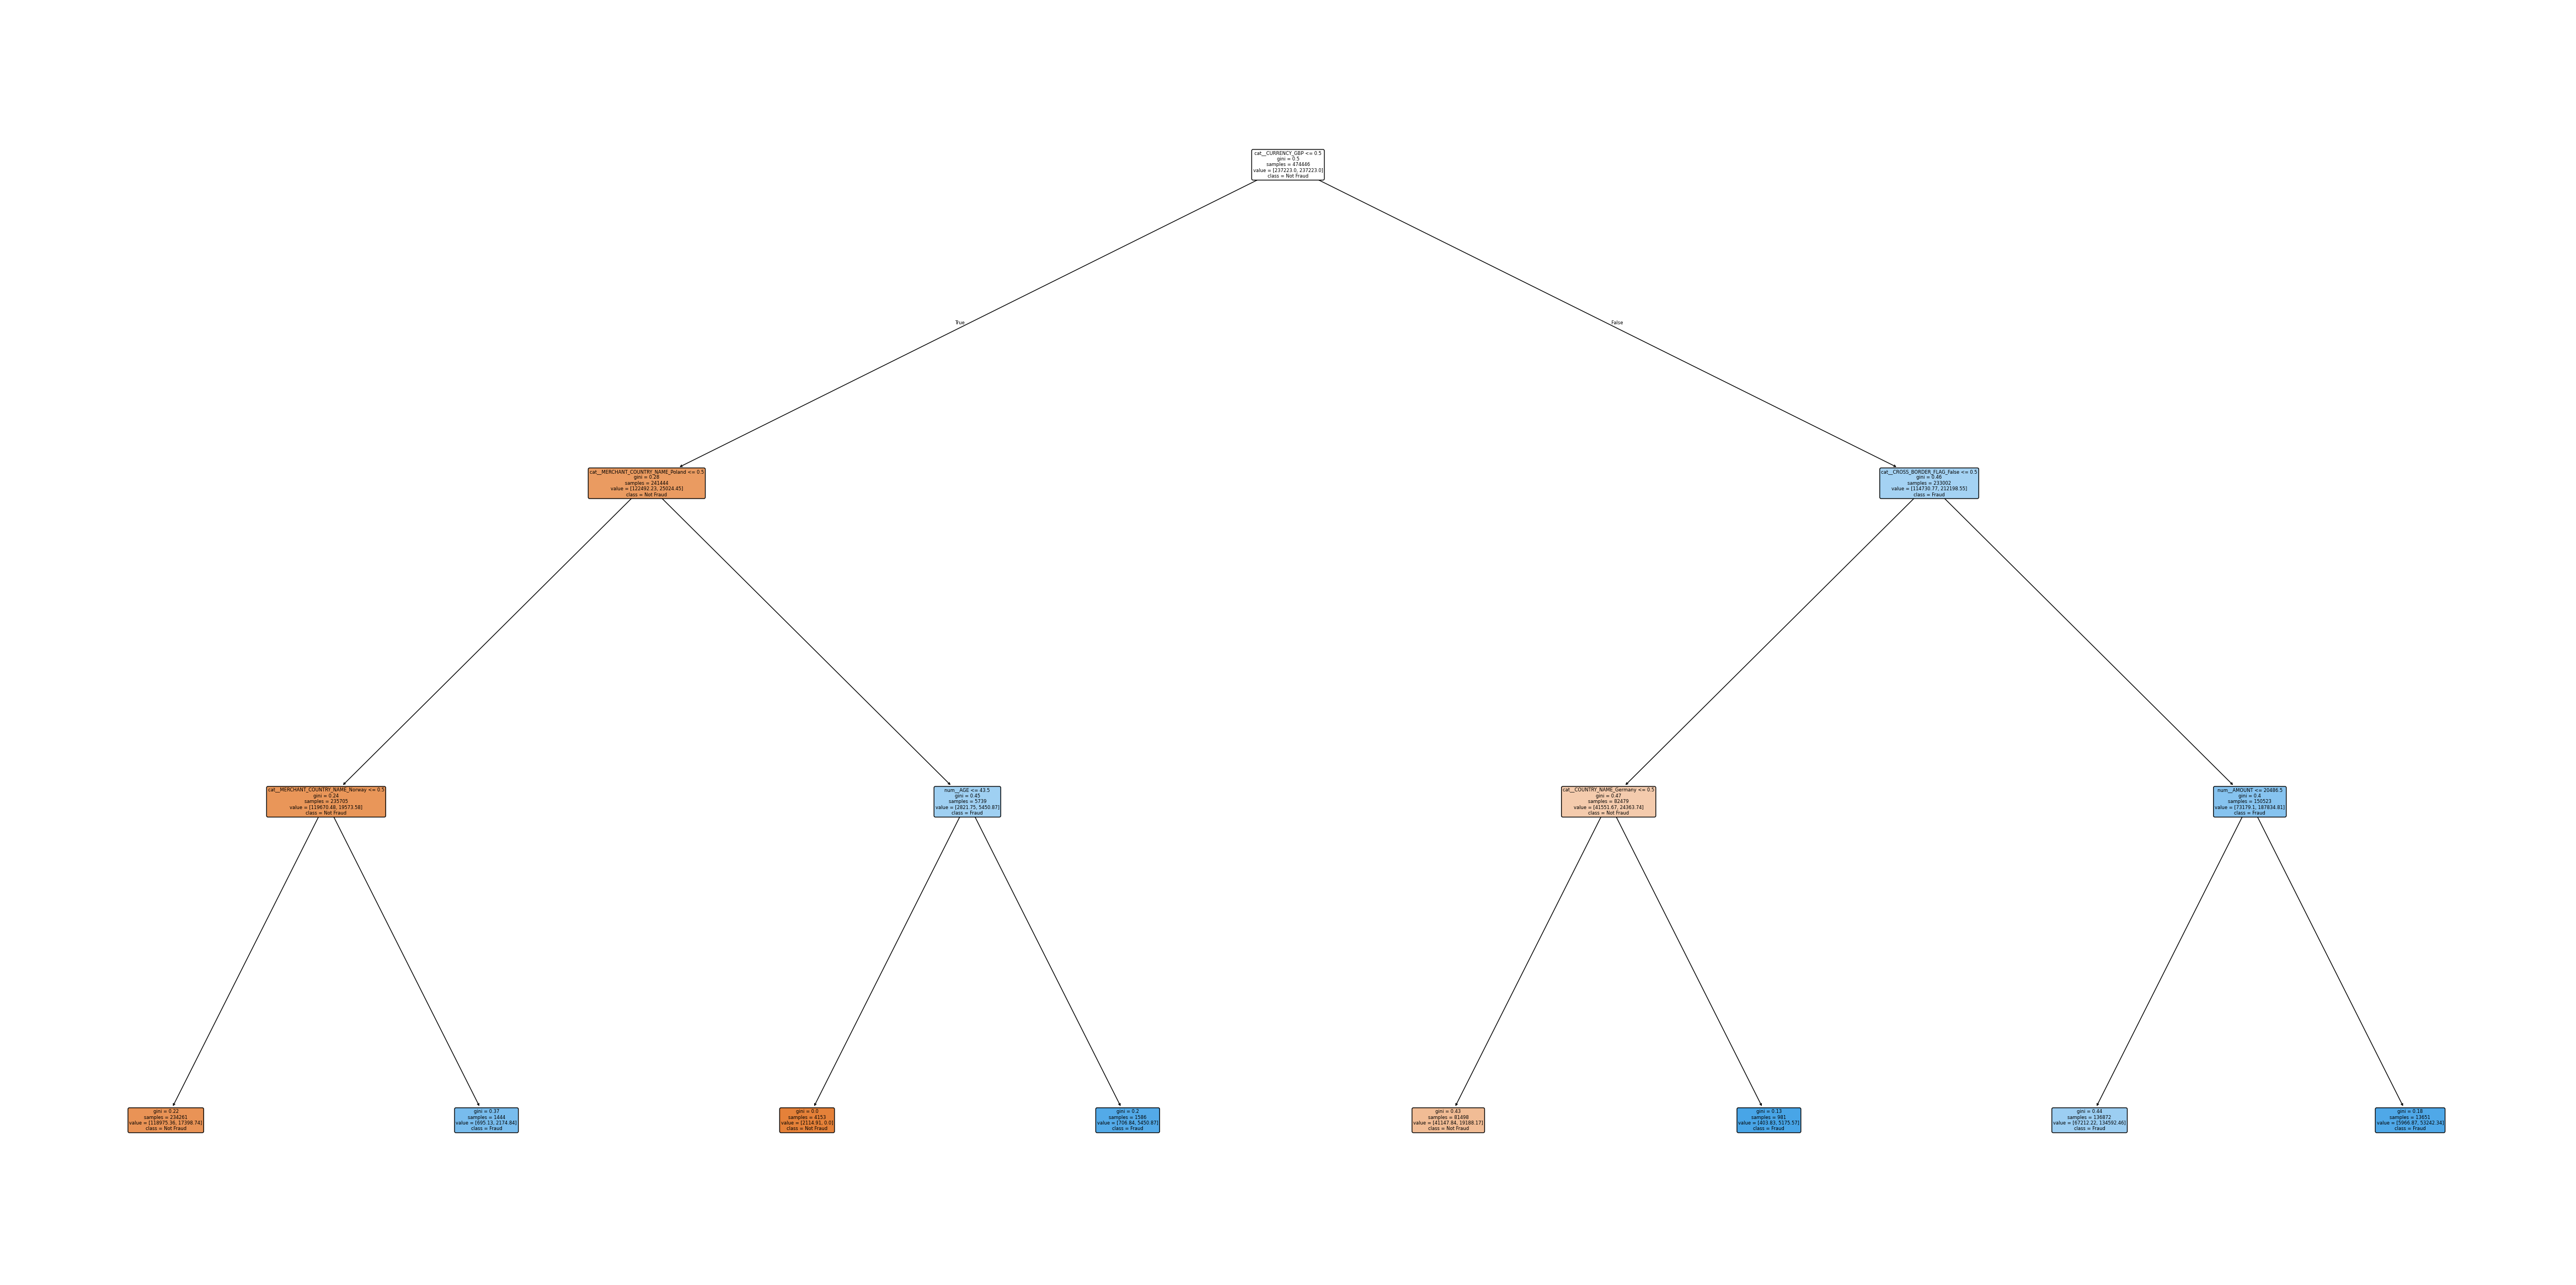

In [71]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

encoded_feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
tree_model = pipeline.named_steps["model"]

plt.figure(figsize=(60, 30))

plot_tree(
    tree_model,
    feature_names=encoded_feature_names,
    class_names=["Not Fraud", "Fraud"],
    filled=True,
    rounded=True,
    fontsize=6,
    proportion=False,
    precision=2
)

plt.savefig(
    "decision_tree_visual_large.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [68]:
# Get trained components
preprocessor = pipeline.named_steps["preprocessor"]
tree_model = pipeline.named_steps["model"]

# Transform X_test
X_test_transformed = preprocessor.transform(X_test)

# Assign each transaction to a decision-tree leaf/cluster
leaf_ids = tree_model.apply(X_test_transformed)

# Create cluster dataframe
cluster_df = X_test.copy()
cluster_df["IS_FRAUD"] = y_test.values
cluster_df["cluster_id"] = leaf_ids

# Fraud rate by cluster
cluster_fraud_rate = cluster_df.groupby("cluster_id").agg(
    transactions=("IS_FRAUD", "count"),
    fraud_transactions=("IS_FRAUD", "sum")
).reset_index()

cluster_fraud_rate["fraud_rate_pct"] = (
    cluster_fraud_rate["fraud_transactions"] / cluster_fraud_rate["transactions"] * 100
).round(2)

cluster_fraud_rate = cluster_fraud_rate.sort_values(
    "fraud_rate_pct",
    ascending=False
)

cluster_fraud_rate

,cluster_id,transactions,fraud_transactions,fraud_rate_pct
5,11,379,59,15.57
7,14,5864,853,14.55
3,7,649,82,12.63
1,4,616,29,4.71
6,13,58998,2084,3.53
4,10,35091,304,0.87
0,3,100080,282,0.28
2,6,1658,0,0.00


In [69]:
from sklearn.tree import _tree

tree_model = pipeline.named_steps["model"]
encoded_feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

def get_leaf_rules(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined"
        for i in tree_.feature
    ]

    leaf_rules = []

    def recurse(node, rules):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]

            left_rules = rules + [f"{name} <= {threshold:.2f}"]
            right_rules = rules + [f"{name} > {threshold:.2f}"]

            recurse(tree_.children_left[node], left_rules)
            recurse(tree_.children_right[node], right_rules)
        else:
            leaf_rules.append({
                "cluster_id": node,
                "rules": " AND ".join(rules)
            })

    recurse(0, [])
    return pd.DataFrame(leaf_rules)

leaf_rules_df = get_leaf_rules(tree_model, encoded_feature_names)

leaf_rules_df

,cluster_id,rules
0,3,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_CO...
1,4,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_CO...
2,6,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_CO...
3,7,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_CO...
4,10,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER...
5,11,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER...
6,13,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER...
7,14,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER...


In [72]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_columns", None)

cluster_fraud_rate_with_rules = cluster_fraud_rate.merge(
    leaf_rules_df,
    on="cluster_id",
    how="left"
)

cluster_fraud_rate_with_rules = cluster_fraud_rate_with_rules.sort_values(
    "fraud_rate_pct",
    ascending=False
).reset_index(drop=True)

cluster_fraud_rate_with_rules

,cluster_id,transactions,fraud_transactions,fraud_rate_pct,rules
0,11,379,59,15.57,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER_FLAG_False <= 0.50 AND cat__COUNTRY_NAME_Germany > 0.50
1,14,5864,853,14.55,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER_FLAG_False > 0.50 AND num__AMOUNT > 20486.50
2,7,649,82,12.63,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Poland > 0.50 AND num__AGE > 43.50
3,4,616,29,4.71,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Poland <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Norway > 0.50
4,13,58998,2084,3.53,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER_FLAG_False > 0.50 AND num__AMOUNT <= 20486.50
5,10,35091,304,0.87,cat__CURRENCY_GBP > 0.50 AND cat__CROSS_BORDER_FLAG_False <= 0.50 AND cat__COUNTRY_NAME_Germany <= 0.50
6,3,100080,282,0.28,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Poland <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Norway <= 0.50
7,6,1658,0,0.00,cat__CURRENCY_GBP <= 0.50 AND cat__MERCHANT_COUNTRY_NAME_Poland > 0.50 AND num__AGE <= 43.50


In [33]:
feature_importance.head(30)

,feature,importance
14,cat__CURRENCY_GBP,5.337731e-01
256,cat__CROSS_BORDER_FLAG_False,1.472890e-01
259,num__AGE,7.052865e-02
258,num__AMOUNT,5.642640e-02
206,cat__MERCHANT_COUNTRY_NAME_Poland,4.792939e-02
45,cat__COUNTRY_NAME_Germany,4.335793e-02
3,cat__TYPE_P2P,2.934559e-02
138,cat__MERCHANT_COUNTRY_NAME_Gibraltar,2.590716e-02
197,cat__MERCHANT_COUNTRY_NAME_Norway,2.550403e-02
4,cat__TYPE_TOPUP,1.053780e-02


##### Insights in data exploration 

1. There are only null fields in MERCHANT_COUNTRY column
2. There are some exceptions that I needed to threat in dataset to be able to give most accurate result

In [127]:
from pathlib import Path

file_path = Path("fin_crime_data.csv")

with open(file_path, "r", encoding="utf-8", errors="replace") as f:
    for i in range(5):
        print(f.readline())

USER_ID,TYPE,AMOUNT,CURRENCY,MERCHANT_COUNTRY,KYC,BIRTH_YEAR,COUNTRY,IS_FRAUD

7285c1ec-31d0-4022-b311-0ad9227ef7f4,CARD_PAYMENT,3738,GBP,AUS,PASSED,1963,GB,False

20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,588,GBP,CA,PASSED,1988,GB,False

0fe472c9-cf3e-4e43-90f3-a0cfb6a4f1f0,CARD_PAYMENT,1264,GBP,UKR,PASSED,1977,GB,False

20100a1d-12bc-41ed-a5e1-bc46216e9696,CARD_PAYMENT,66,GBP,CA,PASSED,1988,GB,False



In [128]:
import csv

with open("fin_crime_data.csv", "r", encoding="utf-8", errors="replace") as f:
    sample = f.read(5000)

sniffer = csv.Sniffer()
dialect = sniffer.sniff(sample)

print("Detected delimiter:", repr(dialect.delimiter))

Detected delimiter: ','
